# 08 -- CAD Export & Propulsion Integration

Complete CAD pipeline:
1. STL/STEP export (bare OML)
2. Propulsion duct placement & clearance validation
3. Cross-section analysis
4. Duct aerodynamic performance
5. Integrated STEP export (OML + duct booleans)


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from pathlib import Path

from src.parameterization.design_variables import BWBParams, params_from_vector
from src.parameterization.bwb_aircraft import (
    build_airplane, build_body_airfoil, compute_wing_area,
    compute_aspect_ratio, compute_mac, compute_internal_volume,
    estimate_structural_mass,
)
from src.aero.evaluator import AeroEvaluator
from src.config import load_all
from src.propulsion.edf_model import EDF_70MM, duct_fits_in_body
from src.propulsion.duct_geometry import (
    compute_duct_placement, compute_duct_structure_mass,
    validate_duct_clearance, compute_duct_centerline,
    duct_cross_section,
    build_intake_geometry, build_sduct_geometry,
    build_edf_housing, build_exhaust_geometry,
)
from src.propulsion.duct_aero import compute_duct_aero, print_duct_aero_summary
from src.visualization.style import apply_style, COLORS
apply_style()

In [2]:
%load_ext autoreload
%autoreload 2

## 1. Load Best Design

In [3]:
try:
    best_x = np.load('../output/best_x_v2.npy')
    params = params_from_vector(best_x)
    print('Loaded v2 optimized design (real CG + elevon trim)')
except FileNotFoundError:
    try:
        best_x = np.load('../output/best_x.npy')
        params = params_from_vector(best_x)
        print('Loaded v1 design (fallback)')
    except FileNotFoundError:
        params = BWBParams()
        print('Using default params')

cfg = load_all()
mission = cfg['mission']
evaluator = AeroEvaluator(
    mission=mission, feasibility=cfg['feasibility'],
    controls=cfg['controls'], cg_config=cfg['cg'],
    avl_command=cfg['avl_command'],
    aero_model=cfg['aero_model'], structure_config=cfg['structure'],
    use_cg=True,
)
result = evaluator.evaluate(params)

Loaded v2 optimized design (real CG + elevon trim)


## 2. Export STL

In [4]:
from src.visualization.export import export_aircraft_stl, export_aircraft_step

out_dir = Path('../output/cad_export')
out_dir.mkdir(parents=True, exist_ok=True)

# STL (triangulated mesh, for visualization)
n_tri = export_aircraft_stl(params, str(out_dir / 'neuron_v2.stl'))
print(f'STL exported: {n_tri} triangles -> {out_dir}/neuron_v2.stl')

# STEP (watertight solid via ThruSections loft)
metrics = export_aircraft_step(params, str(out_dir / 'neuron_v2_solid.step'))
print(f'STEP exported: {metrics["file_size_kb"]:.0f} KB -> {metrics["path"]}')
print(f'  Valid: {metrics["is_valid"]}  Volume: {metrics["volume_mm3"]/1e3:.1f} cm3')

STL exported: 16878 triangles -> ..\output\cad_export/neuron_v2.stl
STEP exported: 1749 KB -> ..\output\cad_export\neuron_v2_solid.step
  Valid: True  Volume: 6347.5 cm3


## 3. Export CAD Profiles

In [5]:
from src.visualization.export import export_cad_profiles

assembly = export_cad_profiles(params, str(out_dir))
print(f'CAD profiles exported to {out_dir}/')
print(f'Sections: {len(assembly["sections"])}')

CAD profiles exported to ..\output\cad_export/
Sections: 10


## 4. EDF Positioning

In [6]:
from src.propulsion.duct_aero import compute_duct_aero, print_duct_aero_summary
from src.propulsion.duct_geometry import compute_duct_centerline, duct_cross_section
from src.parameterization.bwb_aircraft import build_body_airfoil

# Compute duct placement from geometry + EDF spec
placement = compute_duct_placement(params, EDF_70MM)

print('═══ EDF Integration ═══')
body_chord = params.body_root_chord
body_height = params.body_tc_root * body_chord
print(f'  Body chord       : {body_chord*1000:.0f} mm')
print(f'  Body height (max): {body_height*1000:.1f} mm')
print(f'  EDF duct OD      : {EDF_70MM.duct_outer_diameter*1000:.0f} mm')
print(f'  Duct fits        : {duct_fits_in_body(params.body_tc_root, body_chord, EDF_70MM)}')
print(f'  Intake x/c       : {placement.intake_x_frac:.2f} ({placement.intake_x*1000:.0f} mm)')
print(f'  Fan x/c          : {placement.fan_x_frac:.2f} ({placement.fan_x*1000:.0f} mm)')
print(f'  Exhaust x/c      : {placement.exhaust_x_frac:.2f} ({placement.exhaust_x*1000:.0f} mm)')
print(f'  Duct mass        : {compute_duct_structure_mass(placement)*1000:.0f} g')

═══ EDF Integration ═══
  Body chord       : 518 mm
  Body height (max): 102.7 mm
  EDF duct OD      : 78 mm
  Duct fits        : True
  Intake x/c       : 0.04 (21 mm)
  Fan x/c          : 0.44 (229 mm)
  Exhaust x/c      : 0.83 (428 mm)
  Duct mass        : 138 g


## 5. Design Report

In [7]:
print('===================================================')
print('       nEUROn v2 -- Final Design Report')
print('===================================================')
print(f'\nGeometry:')
print(f'  Span             : {2*params.half_span:.2f} m')
print(f'  Wing root chord  : {params.wing_root_chord*1000:.0f} mm')
print(f'  Body chord       : {params.body_root_chord*1000:.0f} mm')
print(f'  Body width       : {2*params.body_halfwidth*1000:.0f} mm')
print(f'  Taper ratio      : {params.taper_ratio:.3f}')
print(f'  LE sweep (wing)  : {params.le_sweep_deg:.1f} deg')
print(f'  Wing area        : {compute_wing_area(params)*1e4:.0f} cm2')
print(f'  Aspect ratio     : {compute_aspect_ratio(params):.2f}')
print(f'\nAerodynamics:')
print(f'  L/D              : {result["L_over_D"]:.2f}')
print(f'  CL               : {result["CL"]:.4f}')
print(f'  CD               : {result["CD"]:.5f}')
print(f'  Static margin    : {result["static_margin"]*100:.1f}% MAC')
print(f'\nControl (v2):')
print(f'  CG x/c           : {result.get("x_cg_frac", 0):.3f}')
print(f'  Elevon deflection : {result.get("elevon_deflection", 0):.1f} deg')
print(f'  Cn_beta          : {result["Cn_beta"]:.4f}')
print(f'  Cl_beta          : {result.get("Cl_beta", 0):.4f}')
print(f'\nStructure:')
print(f'  Struct mass      : {result["struct_mass"]*1000:.0f} g')
print(f'  Internal volume  : {result["internal_volume"]*1e6:.0f} cm3')
print(f'\nPropulsion:')
print(f'  T/D              : {result["T_over_D"]:.2f}')
print(f'  Endurance        : {result["endurance_min"]:.1f} min')
print(f'  Range            : {result["range_km"]:.1f} km')
print(f'\nFeasible: {result["is_feasible"]}')

       nEUROn v2 -- Final Design Report

Geometry:
  Span             : 1.28 m
  Wing root chord  : 264 mm
  Body chord       : 518 mm
  Body width       : 223 mm
  Taper ratio      : 0.208
  LE sweep (wing)  : 31.1 deg
  Wing area        : 2554 cm2
  Aspect ratio     : 6.39

Aerodynamics:
  L/D              : 12.00
  CL               : 0.2031
  CD               : 0.01693
  Static margin    : 20.2% MAC

Control (v2):
  CG x/c           : 0.427
  Elevon deflection : -3.2 deg
  Cn_beta          : 0.0063
  Cl_beta          : -0.0514

Structure:
  Struct mass      : 713 g
  Internal volume  : 1475 cm3

Propulsion:
  T/D              : 1.45
  Endurance        : 8.9 min
  Range            : 13.4 km

Feasible: True


---

# Part 2 (from 09_propulsion_integration.ipynb)


## 1. Body Envelope & Clearance Validation

Automated check that the duct fits within the body OML at every station along the centerline.

In [8]:
# Validate clearance (min 5mm margin)
all_ok, clr_results = validate_duct_clearance(placement, params, min_clearance_mm=5.0)

# Print summary table at key stations
print("Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status")
print("-" * 82)
step = max(1, len(clr_results) // 10)
for r in clr_results[::step]:
    status = "OK" if r.is_ok else "** NOK **"
    line = f"  {r.x_frac:5.2f}   {r.centerline_z_mm:+6.1f}   {r.duct_half_h_mm:5.1f}   "
    line += f"{r.body_z_upper_mm:+6.1f}  {r.body_z_lower_mm:+6.1f}  "
    line += f"{r.clearance_top_mm:+6.1f}  {r.clearance_bot_mm:+6.1f}   {status}"
    print(line)

min_top = min(r.clearance_top_mm for r in clr_results)
min_bot = min(r.clearance_bot_mm for r in clr_results)
print(f"Min clearance -- top: {min_top:.1f} mm, bot: {min_bot:.1f} mm")

if all_ok:
    print("Overall: PASS (all stations >= 5mm margin)")
else:
    violations = [r for r in clr_results if not r.is_ok]
    print(f"Overall: WARNING -- {len(violations)} station(s) below 5mm threshold")
    for v in violations[:5]:
        print(f"  x/c={v.x_frac:.3f}  top={v.clearance_top_mm:+.1f}mm  bot={v.clearance_bot_mm:+.1f}mm")
    if min_top < -1.0 or min_bot < -1.0:
        print("CRITICAL: Duct penetrates body envelope")
    else:
        print("Note: minor violations, adjustable via duct centerline offset")


Station    x/c    CL_z    Duct_hh  OML_up  OML_lo  Clr_top  Clr_bot  Status
----------------------------------------------------------------------------------
   0.24    +12.8     8.8    +77.9   -39.2   +65.1   +43.2   OK
   0.29    +14.3    14.6    +78.9   -35.6   +64.6   +35.3   OK
   0.33    +17.7    21.1    +79.0   -32.5   +40.1   +29.1   OK
   0.37    +21.8    28.3    +78.5   -29.5   +28.4   +23.0   OK
   0.41    +25.0    34.2    +77.5   -26.7   +18.3   +17.4   OK
   0.46    +25.9    35.1    +75.4   -23.2   +14.4   +14.0   OK
   0.54    +24.2    34.9    +70.3   -18.0   +46.1   +42.3   OK
   0.62    +21.1    32.5    +63.2   -13.6   +42.1   +34.7   OK
   0.70    +17.7    27.6    +54.4    -9.9   +36.7   +27.5   OK
   0.77    +15.0    21.0    +43.9    -7.1   +28.9   +22.1   OK
Min clearance -- top: 11.7 mm, bot: 8.7 mm
Overall: PASS (all stations >= 5mm margin)


## 2. Longitudinal Integration (XZ plane, y=0)

Body airfoil cross-section with duct centerline, EDF outline, and clearance bands.

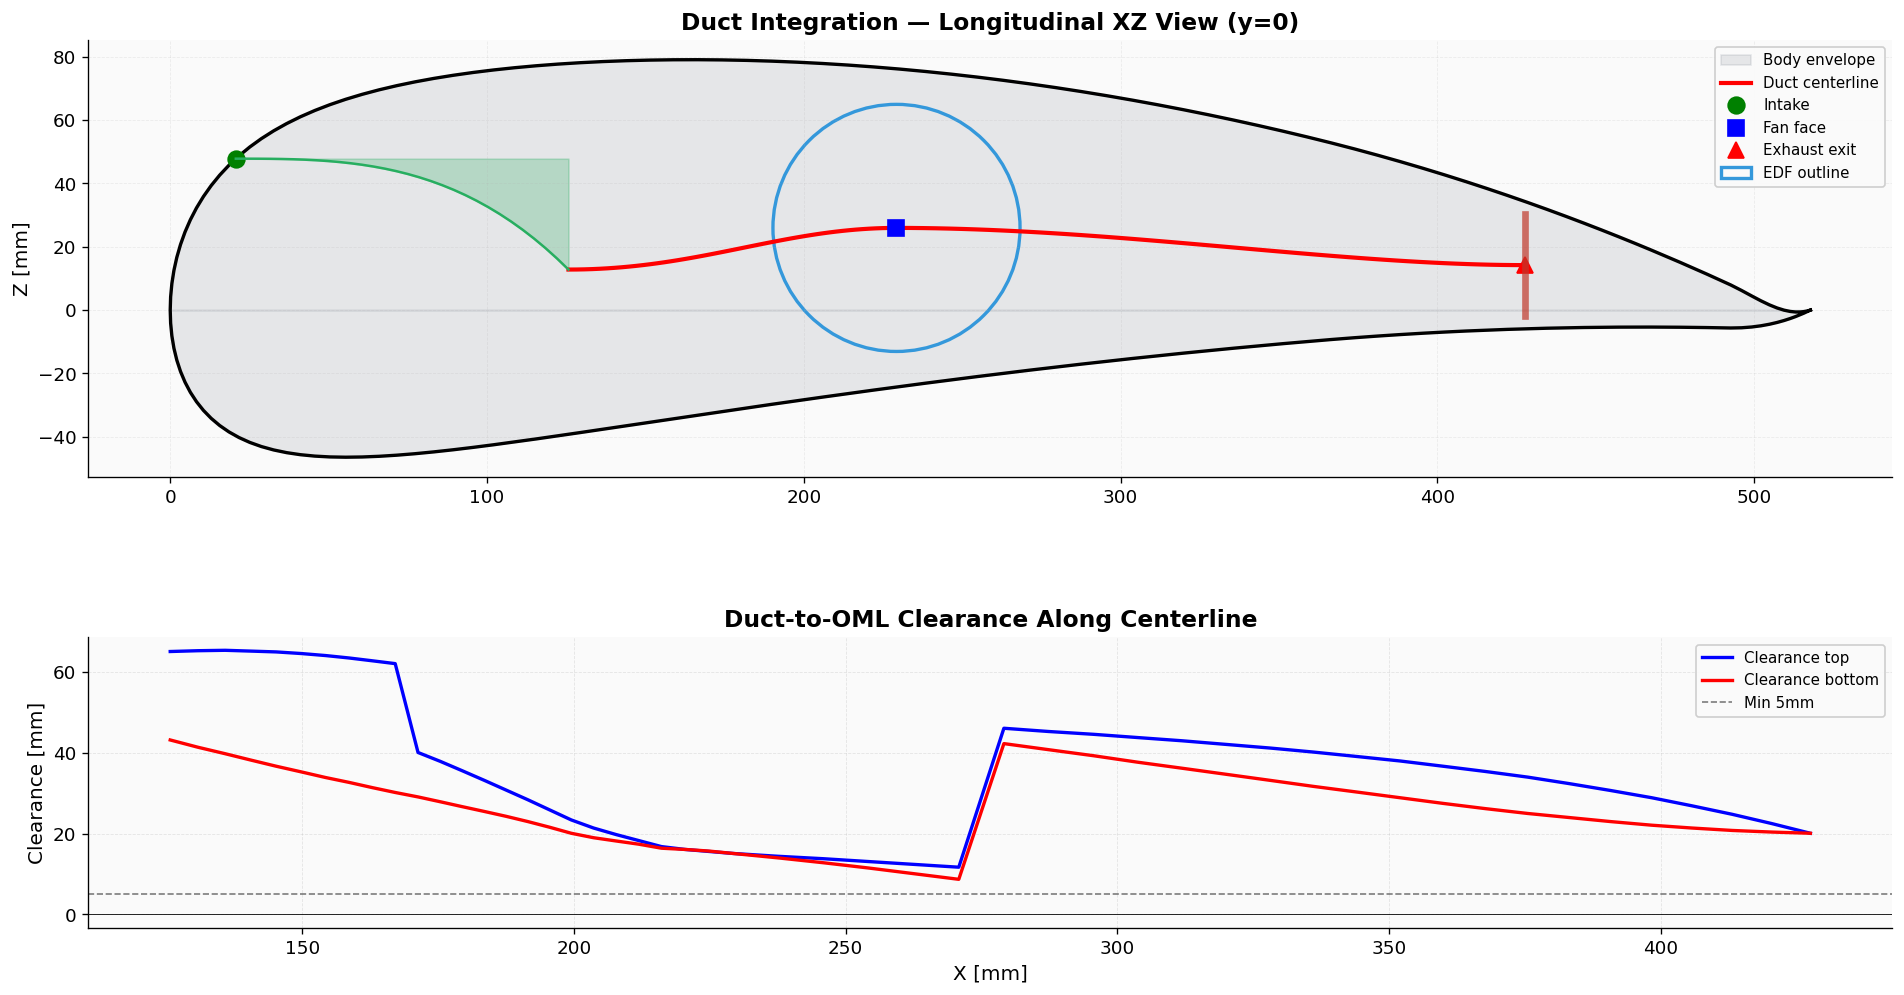

In [9]:
bc = body_chord  # shorthand
# Body airfoil outline
af = build_body_airfoil(tc=params.body_tc_root, camber=params.body_camber,
                        reflex=params.body_reflex, le_droop=params.body_le_droop,
                        n_pts=100)
af_x = af.coordinates[:, 0] * bc * 1000
af_z = af.coordinates[:, 1] * bc * 1000

# Duct centerline
centerline = compute_duct_centerline(placement, n_pts=100)

# Clearance envelope from validation results
clr_x = [r.x_mm for r in clr_results]
clr_top = [r.clearance_top_mm for r in clr_results]
clr_bot = [r.clearance_bot_mm for r in clr_results]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), height_ratios=[3, 1])

# --- Top: XZ integration view ---
ax1.fill_between(af_x, af_z, alpha=0.1, color='#2c3e50', label='Body envelope')
ax1.plot(af_x, af_z, 'k-', linewidth=2)

# Duct centerline
ax1.plot(centerline[:, 0]*1000, centerline[:, 2]*1000,
         'r-', linewidth=2.5, label='Duct centerline')

# Key stations
ax1.plot(placement.intake_x*1000, placement.intake_z*1000,
         'go', markersize=10, label='Intake')
ax1.plot(placement.fan_x*1000, placement.fan_z*1000,
         'bs', markersize=10, label='Fan face')
ax1.plot(placement.exhaust_x*1000, placement.exhaust_z*1000,
         'r^', markersize=10, label='Exhaust exit')

# EDF circle
fan_r = placement.duct_od / 2 * 1000
fan_circle = Circle((placement.fan_x*1000, placement.fan_z*1000), fan_r,
                     fill=False, color='#3498db', linewidth=2, label='EDF outline')
ax1.add_patch(fan_circle)

# Intake scoop
ramp_x = np.linspace(0, placement.intake_length*1000, 30)
ramp_depth = placement.intake_depth*1000 * (ramp_x / (placement.intake_length*1000))**3
ix_mm = placement.intake_x * 1000
iz_mm = placement.intake_z * 1000
ax1.fill_between(ix_mm + ramp_x, iz_mm, iz_mm - ramp_depth,
                 alpha=0.25, color='#27ae60')
ax1.plot(ix_mm + ramp_x, iz_mm - ramp_depth, '-', color='#27ae60', linewidth=1.5)

# Exhaust slot
ex_mm = placement.exhaust_x * 1000
ez_mm = placement.exhaust_z * 1000
eh_mm = placement.exhaust_height / 2 * 1000
ax1.plot([ex_mm, ex_mm], [ez_mm-eh_mm, ez_mm+eh_mm],
         '-', color='#c0392b', linewidth=4, alpha=0.7)

ax1.set_ylabel('Z [mm]')
ax1.set_title('Duct Integration — Longitudinal XZ View (y=0)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)

# --- Bottom: Clearance diagram ---
ax2.plot(clr_x, clr_top, 'b-', linewidth=2, label='Clearance top')
ax2.plot(clr_x, clr_bot, 'r-', linewidth=2, label='Clearance bottom')
ax2.axhline(5.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Min 5mm')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.fill_between(clr_x, clr_top, 0, where=[t < 0 for t in clr_top],
                 alpha=0.3, color='red')
ax2.fill_between(clr_x, clr_bot, 0, where=[b < 0 for b in clr_bot],
                 alpha=0.3, color='red')
ax2.set_xlabel('X [mm]')
ax2.set_ylabel('Clearance [mm]')
ax2.set_title('Duct-to-OML Clearance Along Centerline')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/integration_xz_clearance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Cross-Sections & Transverse Cuts

Cross-section shape evolution (intake → fan → exhaust) and transverse body-vs-duct fit at key stations.

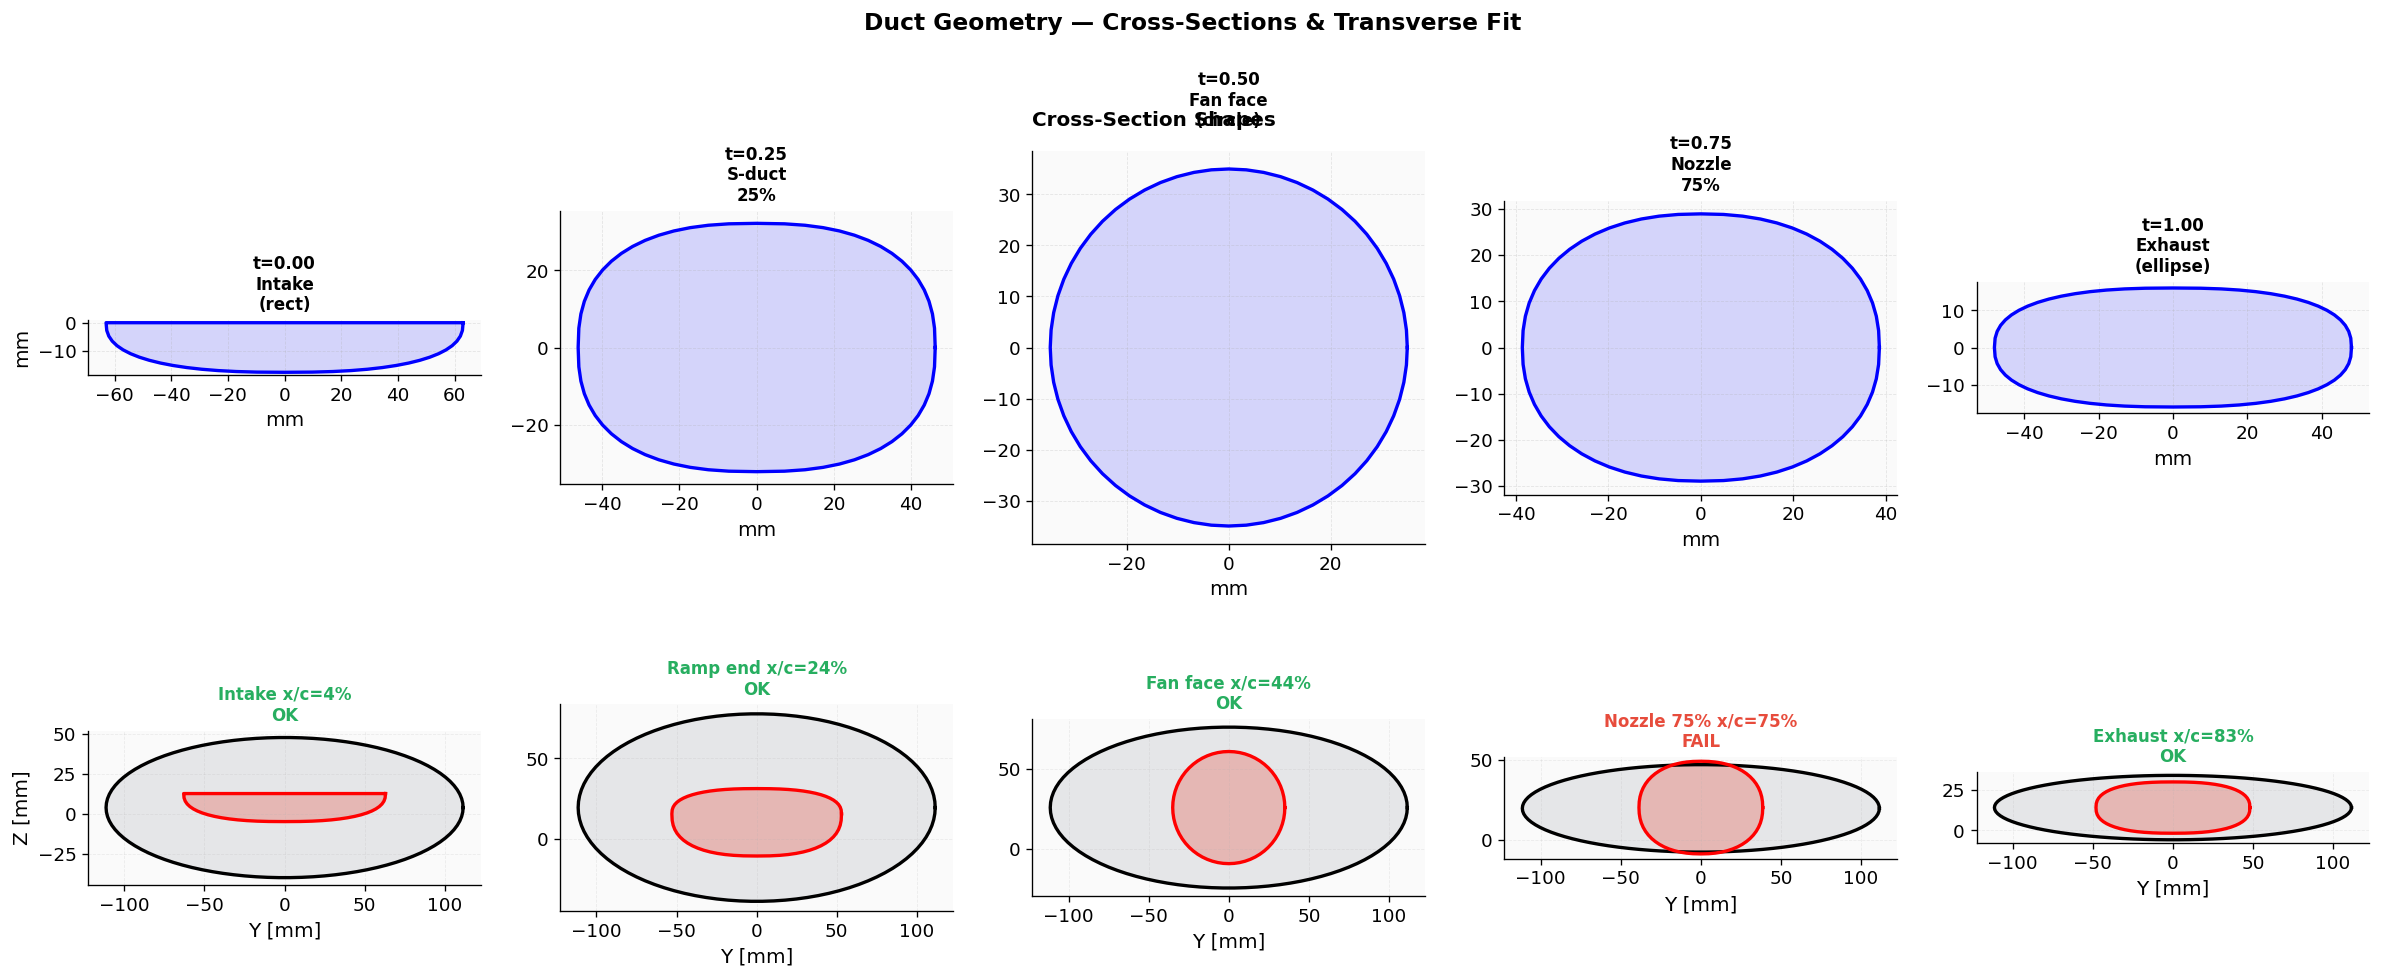

In [10]:
from src.propulsion.duct_geometry import _body_surface_z

fig, axes = plt.subplots(2, 5, figsize=(20, 9))

stations = [0.0, 0.25, 0.5, 0.75, 1.0]
names = ['Intake\n(rect)', 'S-duct\n25%', 'Fan face\n(circle)', 'Nozzle\n75%', 'Exhaust\n(ellipse)']

# Row 1: Cross-section shapes
for ax, t, name in zip(axes[0], stations, names):
    cs = duct_cross_section(t, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, 'b-', linewidth=2)
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000, alpha=0.15, color='blue')
    ax.set_title(f't={t:.2f}\n{name}', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('mm')
    if t == 0.0:
        ax.set_ylabel('mm')

# Row 2: Transverse body-vs-duct cuts
cs_stations = [
    (placement.intake_x_frac, 0.0, 'Intake'),
    ((placement.intake_x + placement.intake_length) / bc, 0.15, 'Ramp end'),
    (placement.fan_x_frac, 0.5, 'Fan face'),
    (0.75, 0.75, 'Nozzle 75%'),
    (placement.exhaust_x_frac, 1.0, 'Exhaust'),
]

cl = compute_duct_centerline(placement, n_pts=100)

for ax, (x_frac, t_cs, name) in zip(axes[1], cs_stations):
    z_up, z_cam, z_lo = _body_surface_z(x_frac, params.body_tc_root, params.body_camber,
                                         params.body_reflex, params.body_le_droop)
    z_up_mm = z_up * bc * 1000
    z_lo_mm = z_lo * bc * 1000
    z_cam_mm = z_cam * bc * 1000
    body_hw_mm = params.body_halfwidth * 1000

    # Body cross-section (elliptical approximation)
    th_up = np.linspace(0, np.pi, 50)
    th_lo = np.linspace(np.pi, 2*np.pi, 50)
    b_up = z_up_mm - z_cam_mm
    b_lo = z_cam_mm - z_lo_mm
    y_body = np.concatenate([body_hw_mm * np.cos(th_up), body_hw_mm * np.cos(th_lo)])
    z_body = np.concatenate([z_cam_mm + b_up * np.sin(th_up),
                             z_cam_mm + b_lo * np.sin(th_lo)])
    ax.fill(y_body, z_body, alpha=0.1, color='#2c3e50')
    ax.plot(y_body, z_body, 'k-', linewidth=2)

    # Duct cross-section at centerline z
    cs = duct_cross_section(t_cs, placement, n_pts=64)
    cs_closed = np.vstack([cs, cs[0]])
    idx = int(t_cs * (len(cl) - 1))
    duct_cz = cl[idx, 2] * 1000
    ax.fill(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            alpha=0.3, color='#e74c3c')
    ax.plot(cs_closed[:, 0]*1000, cs_closed[:, 1]*1000 + duct_cz,
            'r-', linewidth=2)

    # Check fit
    duct_top = duct_cz + cs[:, 1].max() * 1000
    duct_bot = duct_cz + cs[:, 1].min() * 1000
    ok = duct_top < z_up_mm and duct_bot > z_lo_mm
    color = '#27ae60' if ok else '#e74c3c'
    ax.set_title(f'{name} x/c={x_frac:.0%}\n{"OK" if ok else "FAIL"}',
                 fontsize=10, color=color, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Y [mm]')
    if ax == axes[1][0]:
        ax.set_ylabel('Z [mm]')

axes[0][2].set_title('Cross-Section Shapes', fontsize=12, fontweight='bold', loc='left', pad=15)
fig.suptitle('Duct Geometry — Cross-Sections & Transverse Fit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/integration_cross_sections.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Aerodynamic Performance

Duct pressure recovery, mass flow, and exit velocity at cruise and across the speed range.

  DUCT AERODYNAMIC PERFORMANCE
  Mass flow rate:       0.2014 kg/s
  Fan face velocity:    42.7 m/s

  Intake capture area:  82.2 cm²
  Fan face area:        38.5 cm²
  Exhaust exit area:    30.8 cm²
  Nozzle area ratio:    0.800

  Pressure recovery:
    Intake (NACA):      0.950
    S-duct:             0.993
    Nozzle:             0.980
    TOTAL:              0.925

  Exit velocity:        53.4 m/s
  Velocity ratio:       2.67
  S-duct offset/L:      0.211
  CD intake increment:  0.00086

  WARNINGS:
    - Intake area 44.1 cm² < required 82.2 cm² (mass flow deficit)


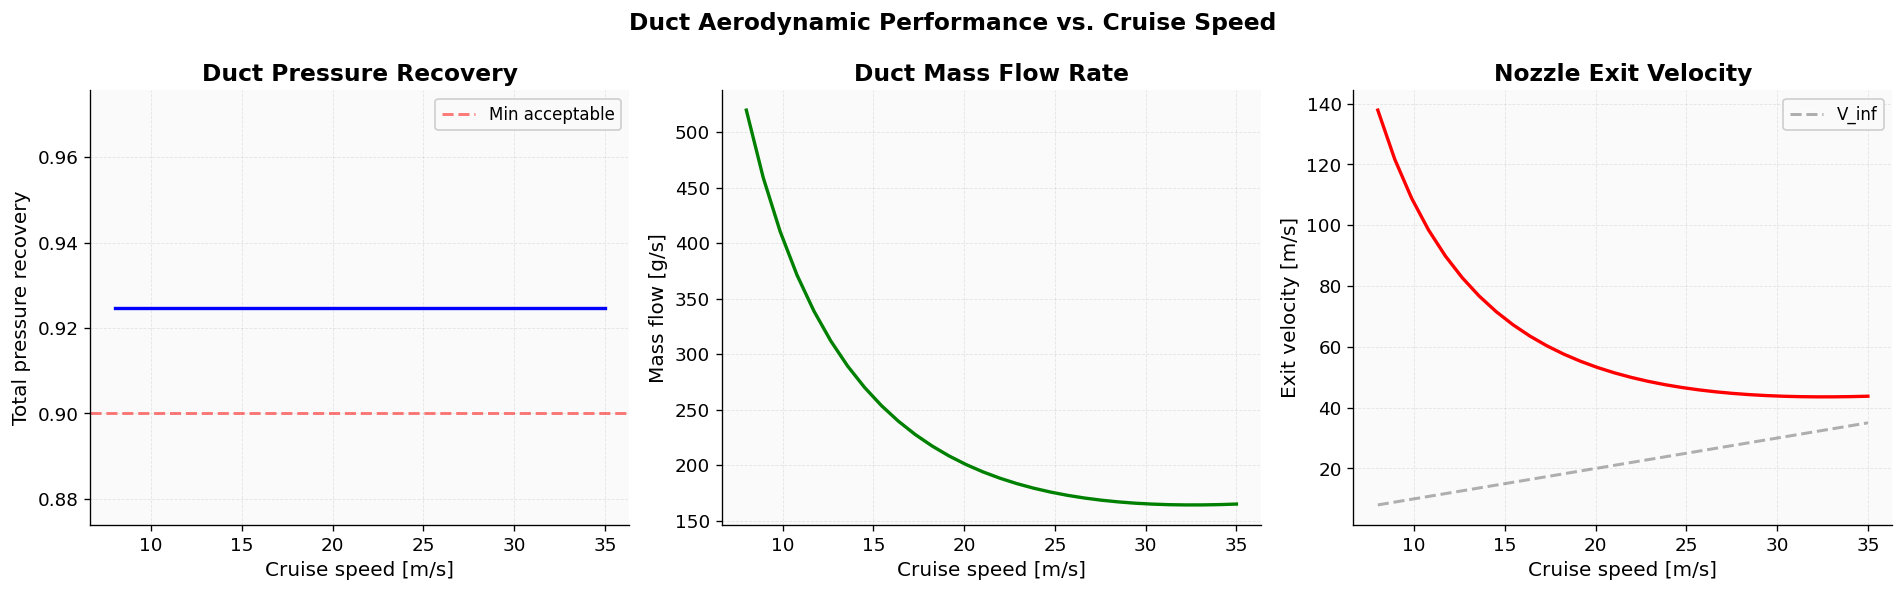

In [11]:
# Detailed summary at cruise speed
aero = compute_duct_aero(placement, EDF_70MM, params, velocity=20.0)
print_duct_aero_summary(aero)

# Performance vs. cruise speed
velocities = np.linspace(8, 35, 30)
pr_totals, mass_flows, exit_vels = [], [], []
for v in velocities:
    r = compute_duct_aero(placement, EDF_70MM, params, velocity=v)
    pr_totals.append(r.pr_total)
    mass_flows.append(r.mass_flow)
    exit_vels.append(r.exit_velocity)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

ax1.plot(velocities, pr_totals, 'b-', linewidth=2)
ax1.axhline(0.90, color='r', linestyle='--', alpha=0.5, label='Min acceptable')
ax1.set_xlabel('Cruise speed [m/s]')
ax1.set_ylabel('Total pressure recovery')
ax1.set_title('Duct Pressure Recovery')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(velocities, np.array(mass_flows)*1000, 'g-', linewidth=2)
ax2.set_xlabel('Cruise speed [m/s]')
ax2.set_ylabel('Mass flow [g/s]')
ax2.set_title('Duct Mass Flow Rate')
ax2.grid(True, alpha=0.3)

ax3.plot(velocities, exit_vels, 'r-', linewidth=2)
ax3.plot(velocities, velocities, 'k--', alpha=0.3, label='V_inf')
ax3.set_xlabel('Cruise speed [m/s]')
ax3.set_ylabel('Exit velocity [m/s]')
ax3.set_title('Nozzle Exit Velocity')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('Duct Aerodynamic Performance vs. Cruise Speed',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/integration_aero_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 3D Visualization

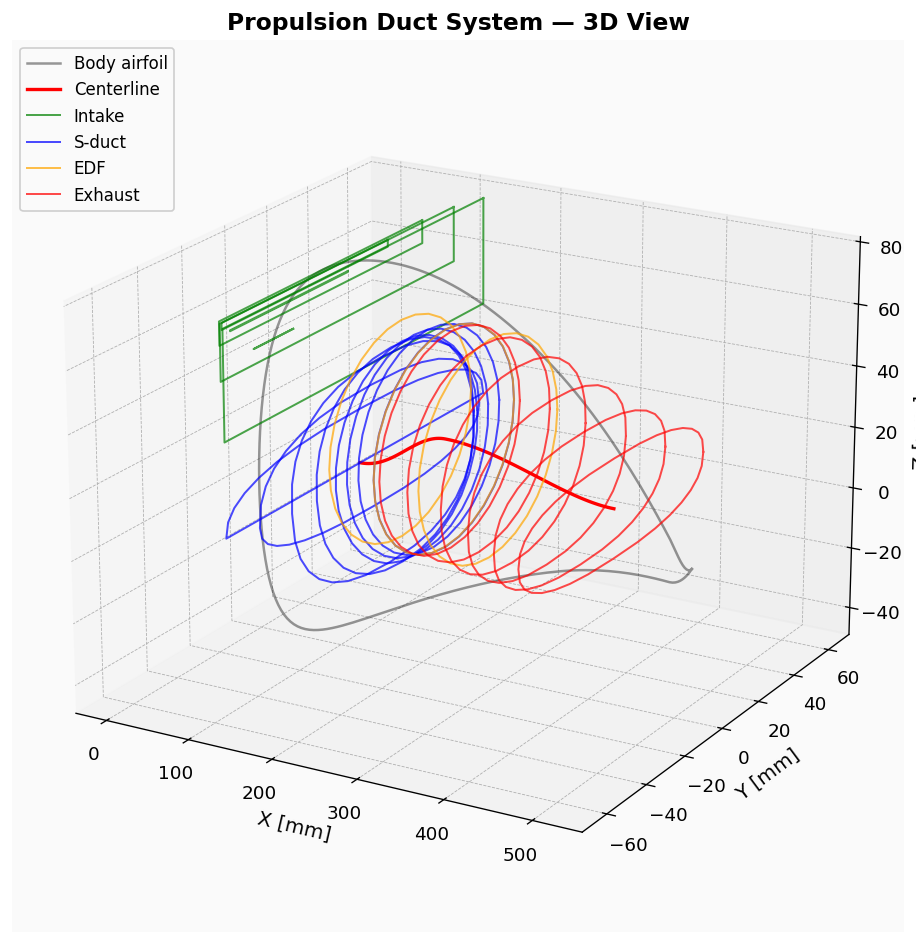

In [12]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Body airfoil outline at y=0
ax.plot(af.coordinates[:, 0] * bc * 1000,
        np.zeros(len(af.coordinates)),
        af.coordinates[:, 1] * bc * 1000,
        'k-', linewidth=1.5, alpha=0.4, label='Body airfoil')

# Duct centerline
ax.plot(centerline[:, 0]*1000, centerline[:, 1]*1000,
        centerline[:, 2]*1000, 'r-', linewidth=2, label='Centerline')

# Component sections
colors = {'Intake': 'green', 'S-duct': 'blue', 'EDF': 'orange', 'Exhaust': 'red'}
components = [
    ('Intake', build_intake_geometry(placement, params, n_profile=32, n_axial=6)),
    ('S-duct', build_sduct_geometry(placement, params, EDF_70MM, n_stations=8, n_profile=32)),
    ('EDF', build_edf_housing(placement, EDF_70MM, n_profile=32, n_axial=3)),
    ('Exhaust', build_exhaust_geometry(placement, params, EDF_70MM, n_stations=6, n_profile=32)),
]

for name, sections in components:
    c = colors[name]
    for i, sec in enumerate(sections):
        sec_closed = np.vstack([sec, sec[0]])
        label = name if i == 0 else None
        ax.plot(sec_closed[:, 0]*1000, sec_closed[:, 1]*1000,
                sec_closed[:, 2]*1000, '-', color=c, linewidth=1.2,
                alpha=0.7, label=label)

ax.set_xlabel('X [mm]')
ax.set_ylabel('Y [mm]')
ax.set_zlabel('Z [mm]')
ax.set_title('Propulsion Duct System — 3D View')
ax.legend(loc='upper left')
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

## 6. CAD Export (STL + STEP)

STL for quick visualization, STEP with boolean-cut intake/exhaust openings for FreeCAD.

The STEP compound contains 2 bodies:
- **Body 1**: OML with intake+exhaust openings cut out
- **Body 2**: Internal duct solid

Toggle visibility in FreeCAD to inspect each separately.

In [13]:
from src.visualization.export import export_aircraft_stl, export_aircraft_step

# --- STL export ---
stl_path = '../output/neuron_v2_with_propulsion.stl'
n_tris = export_aircraft_stl(params, stl_path,
                              include_propulsion=True, edf=EDF_70MM)
print(f'STL: {n_tris} triangles -> {stl_path}')

# --- STEP export (with propulsion boolean cuts) ---
step_path = '../output/cad_export/neuron_v2_with_propulsion.step'
result = export_aircraft_step(params, step_path,
                              include_propulsion=True, edf=EDF_70MM)

print(f'\n--- STEP Export Summary ---')
print(f'  Compound:     {result["file_size_kb"]:.0f} KB  ({result["path"]})')
print(f'  OML only:     {result["oml_size_kb"]:.0f} KB  ({result["oml_path"]})')
print(f'  Duct only:    {result["duct_size_kb"]:.0f} KB  ({result["duct_path"]})')
print(f'  Hinge lines:  {result["hinge_size_kb"]:.0f} KB  ({result.get("hinge_path", "N/A")})')
print(f'  Mode:         {result["compound_mode"]}')
print(f'  Has duct:     {result["has_duct"]}')
print(f'  Has shell:    {result["has_shell"]}')
print(f'  Hinge wires:  {result.get("n_hinge_wires", 0)}')
print(f'  Clearance:    {result["clearance_ok"]}')
print(f'  Valid:        {result["is_valid"]}')
print(f'  Volume:       {result["volume_mm3"]/1e6:.1f} cm3')
print(f'  Surface:      {result["surface_area_mm2"]/1e6:.1f} cm2')

# Verify STEP file size
if result['file_size_kb'] < 300:
    print(f'\n  WARNING: STEP file seems small ({result["file_size_kb"]:.0f} KB < 300 KB)')

print(f'\nTo view hinge lines in FreeCAD:')
print(f'  1. Open {result["path"]}')
print(f'  2. File > Import > {result.get("hinge_path", "")}')
print(f'  3. Select hinge wires, set Line Width=3, Line Color=red')

STL: 19118 triangles -> ../output/neuron_v2_with_propulsion.stl
[prop] 1/6  Building OML solid...
[prop]      OML OK  (1749 KB, 6.3 cm3)
[prop] 2/6  Computing duct placement...
[prop] 3/6  Building internal duct solid...
[prop]      Duct OK (22 sections, 1794 KB)
[prop] 4/6  Validating duct clearance...
[prop]      Clearance OK (min top=11.7mm, min bot=8.7mm)
[prop] 5/6  Building duct shell (coque)...
[prop]      Shell OK (vol=1.3 cm3, 1690 KB)
[prop] 6/6  Boolean: robust Fuse(OML, Shell) + Cut(Duct)...
[v3] Robust STEP boolean pipeline
[v3] Step 1/3: Preprocessing all shapes...
[v3] Step 2/3: Fuse(OML, Shell)...
[fuse] Operand volumes: 6347549.5, 1301158.3 mm³
[fuse] Trying CellsBuilder (fuzzy=0.010)...
[fuse] CellsBuilder result invalid: Result has invalid topology
[fuse] Trying CellsBuilder (fuzzy=0.050)...
[fuse] CellsBuilder result invalid: Result has invalid topology
[fuse] Trying CellsBuilder (fuzzy=0.100)...
[fuse] CellsBuilder result invalid: Result has invalid topology
[fuse]

d:\nEUROn_v2\notebooks\..\src\visualization\export.py:1299: UserWarning: Boolean pipeline failed: Fuse failed: all fuse strategies failed — exporting multi-body fallback
  warnings.warn("Boolean pipeline failed: %s — exporting multi-body fallback" % status)


[prop]      Control surfaces: 6 KB -> ../output/cad_export/neuron_v2_with_propulsion_control_surfaces.iges
[prop] Done: 5296 KB, valid=True, boolean=False, vol=9.3 cm3, hinge_wires=4

--- STEP Export Summary ---
  Compound:     5296 KB  (../output/cad_export/neuron_v2_with_propulsion.step)
  OML only:     1749 KB  (../output/cad_export/neuron_v2_with_propulsion_oml_only.step)
  Duct only:    1794 KB  (../output/cad_export/neuron_v2_with_propulsion_duct_only.step)
  Hinge lines:  6 KB  (../output/cad_export/neuron_v2_with_propulsion_control_surfaces.iges)
  Mode:         multi-body fallback: OML + shell + duct
  Has duct:     True
  Has shell:    True
  Hinge wires:  4
  Clearance:    True
  Valid:        True
  Volume:       9.3 cm3
  Surface:      0.8 cm2

To view hinge lines in FreeCAD:
  1. Open ../output/cad_export/neuron_v2_with_propulsion.step
  2. File > Import > ../output/cad_export/neuron_v2_with_propulsion_control_surfaces.iges
  3. Select hinge wires, set Line Width=3, Line 